# Customer Churn Intelligence — Calibrated Threshold Re-Optimization

## Context

Step 17 **retained sigmoid (Platt) calibration**, which shifts probability outputs. The Step-16 threshold (0.26) was tuned on **uncalibrated** scores and is no longer valid.

This follow-up reruns business threshold optimization on **calibrated validation probabilities** only. The final test set is **not used**.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
from xgboost import XGBClassifier

PROJECT_ROOT = Path("..").resolve()
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
THRESHOLD_TABLE_PATH = REPORTS_DIR / "threshold_analysis_calibrated.csv"
CHOSEN_THRESHOLD_PATH = REPORTS_DIR / "chosen_threshold.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_split import load_split_from_manifest
from src.preprocessing import build_preprocessor

RETENTION_OFFER_COST = 50   # simulated USD per FP contact
LOST_CUSTOMER_COST = 500  # simulated USD per missed churner
RANDOM_STATE = 42
STEP16_UNCALIBRATED_THRESHOLD = 0.26

## 1. Calibrated Validation Probabilities (Step 17 — Sigmoid retained)

In [2]:
split = load_split_from_manifest()
X_train, X_val = split.X_train, split.X_val
y_train = (split.y_train == "Yes").astype(int)
y_val = (split.y_val == "Yes").astype(int)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

preprocessor = build_preprocessor()
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)

xgb = XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8,
    colsample_bytree=1.0, scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1,
)

calibrated_model = CalibratedClassifierCV(xgb, method="sigmoid", cv=5)
calibrated_model.fit(X_train_t, y_train)
y_val_proba = calibrated_model.predict_proba(X_val_t)[:, 1]

print(f"Calibrated probability mean: {y_val_proba.mean():.4f} (uncalibrated was ~0.41)")

Calibrated probability mean: 0.2729 (uncalibrated was ~0.41)


## 2. Threshold Sweep on Calibrated Probabilities

In [3]:
rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    y_pred = (y_val_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    total_cost = fp * RETENTION_OFFER_COST + fn * LOST_CUSTOMER_COST
    rows.append({
        "Threshold": round(float(threshold), 2),
        "Precision": round(precision_score(y_val, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_val, y_pred), 4),
        "F1": round(f1_score(y_val, y_pred, zero_division=0), 4),
        "False_Positives": int(fp),
        "False_Negatives": int(fn),
        "Predicted_Churners": int(y_pred.sum()),
        "Total_Cost_USD": int(total_cost),
    })

threshold_df = pd.DataFrame(rows)
threshold_df.to_csv(THRESHOLD_TABLE_PATH, index=False)

best_row = threshold_df.loc[threshold_df["Total_Cost_USD"].idxmin()]
step16_row = threshold_df.loc[(threshold_df["Threshold"] - STEP16_UNCALIBRATED_THRESHOLD).abs().idxmin()]

print(f"Saved: {THRESHOLD_TABLE_PATH}")
pd.DataFrame([best_row, step16_row], index=["New optimum (calibrated)", "Old Step-16 @ 0.26"])

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\threshold_analysis_calibrated.csv


,Threshold,Precision,Recall,F1,False_Positives,False_Negatives,Predicted_Churners,Total_Cost_USD
New optimum (calibrated),0.10,0.4154,0.9464,0.5773,373.0,15.0,638.0,26150.0
Old Step-16 @ 0.26,0.26,0.5213,0.8286,0.6400,213.0,48.0,445.0,34650.0


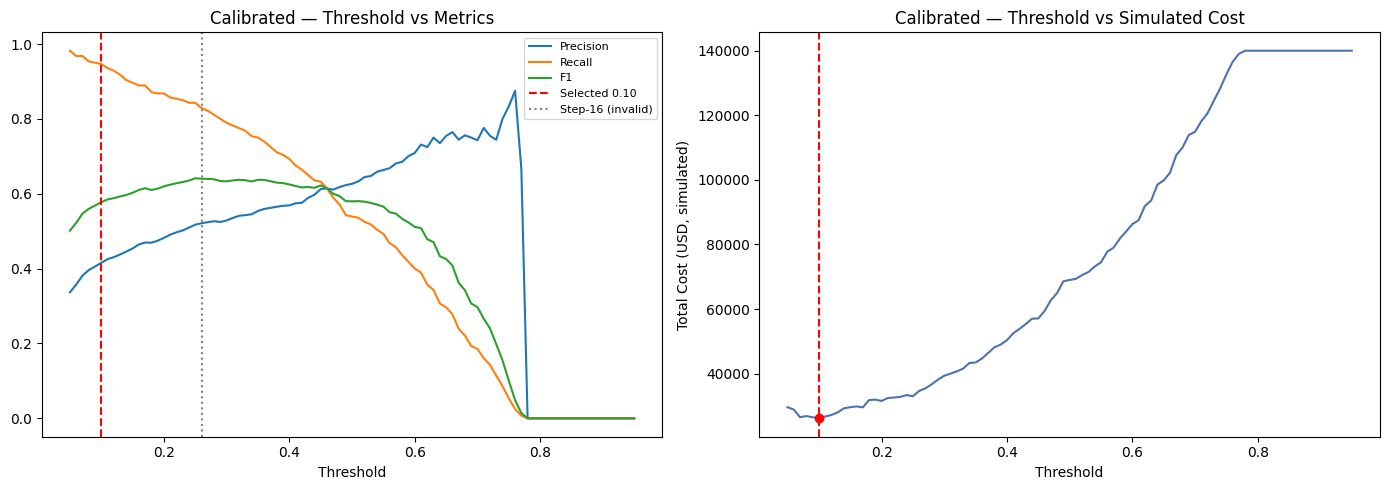

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_df["Threshold"], threshold_df["Precision"], label="Precision")
axes[0].plot(threshold_df["Threshold"], threshold_df["Recall"], label="Recall")
axes[0].plot(threshold_df["Threshold"], threshold_df["F1"], label="F1")
axes[0].axvline(best_row["Threshold"], color="red", linestyle="--", label=f"Selected {best_row['Threshold']:.2f}")
axes[0].axvline(STEP16_UNCALIBRATED_THRESHOLD, color="gray", linestyle=":", label="Step-16 (invalid)")
axes[0].set_title("Calibrated — Threshold vs Metrics")
axes[0].set_xlabel("Threshold")
axes[0].legend(fontsize=8)

axes[1].plot(threshold_df["Threshold"], threshold_df["Total_Cost_USD"], color="#4C72B0")
axes[1].axvline(best_row["Threshold"], color="red", linestyle="--")
axes[1].scatter([best_row["Threshold"]], [best_row["Total_Cost_USD"]], color="red", zorder=5)
axes[1].set_title("Calibrated — Threshold vs Simulated Cost")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Total Cost (USD, simulated)")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "11_calibrated_threshold_optimization.png", dpi=120)
plt.show()

## 3. Save Final Validation Threshold

In [5]:
chosen = {
    "calibration_retained": True,
    "calibration_method": "sigmoid (Platt)",
    "threshold": float(best_row["Threshold"]),
    "threshold_source": "validation_min_simulated_business_cost",
    "probabilities": "calibrated",
    "step16_uncalibrated_threshold": STEP16_UNCALIBRATED_THRESHOLD,
    "step16_threshold_valid_after_calibration": False,
    "validation_metrics_at_chosen_threshold": {
        "Precision": float(best_row["Precision"]),
        "Recall": float(best_row["Recall"]),
        "F1": float(best_row["F1"]),
        "False_Positives": int(best_row["False_Positives"]),
        "False_Negatives": int(best_row["False_Negatives"]),
        "Predicted_Churners": int(best_row["Predicted_Churners"]),
        "Total_Cost_USD_simulated": int(best_row["Total_Cost_USD"]),
    },
    "simulated_cost_assumptions": {
        "retention_offer_cost_usd": RETENTION_OFFER_COST,
        "lost_customer_cost_usd": LOST_CUSTOMER_COST,
    },
    "note": "Tuned on validation only. Test set not used.",
}

CHOSEN_THRESHOLD_PATH.write_text(json.dumps(chosen, indent=2), encoding="utf-8")
print(f"Saved: {CHOSEN_THRESHOLD_PATH}")
chosen

Saved: D:\SE Study\Data Science\ML Projects for Portfolio\customer-churn-intelligence\reports\chosen_threshold.json


{'calibration_retained': True,
 'calibration_method': 'sigmoid (Platt)',
 'threshold': 0.1,
 'threshold_source': 'validation_min_simulated_business_cost',
 'probabilities': 'calibrated',
 'step16_uncalibrated_threshold': 0.26,
 'step16_threshold_valid_after_calibration': False,
 'validation_metrics_at_chosen_threshold': {'Precision': 0.4154,
  'Recall': 0.9464,
  'F1': 0.5773,
  'False_Positives': 373,
  'False_Negatives': 15,
  'Predicted_Churners': 638,
  'Total_Cost_USD_simulated': 26150},
 'simulated_cost_assumptions': {'retention_offer_cost_usd': 50,
  'lost_customer_cost_usd': 500},
 'note': 'Tuned on validation only. Test set not used.'}